Imported Packages

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


Data

In [10]:
data_dict = {
    "UV_HV_650_top_full": {
        "HV" : np.array([650, 650, 650, 650, 650, 650, 650, 650, 650, 650]), #HV,
        "O_V" : np.array([1.446, 1.443, 1.438, 1.421, 1.447, 1.437, 1.433, 1.434, 1.43, 1.443]), #Output Voltage,
        "O_A" : np.array([71.8, 71.6, 71.3, 70.5, 71.8, 71.3, 71.1, 71.1, 70.9, 71.6]), #Output current
        "Temp" : np.array([23.6, 23.5, 23.3, 23.2, 23.3, 23.3, 23.4, 23.4, 23.4, 23.4]), #PMT temperature, degree celcius
        "serial": np.arange(1, 11),
        "xlabel1": "Output Voltage (V)", 
        "xlabel2": "High Voltage (V)",
        "ylabel1": "Output Voltage (V)",
        "ylabel2": "Current (mA)",
        "title": "UV_HV_650_top_full",
        "legend": "R7600 PMT",
        "category": "PMT current scan"
    },
    "UV_HV_650_top_5/6": {
        "HV" : np.array([650, 650, 650, 650, 650, 650, 650, 650, 650, 650]), #HV,
        "O_V" : np.array([1.446, 1.443, 1.438, 1.421, 1.447, 1.437, 1.433, 1.434, 1.43, 1.443]), #Output Voltage,
        "O_A" : np.array([46.87, 46.55, 46.45, 46.29, 46.45, 44.46, 45.56, 46.19, 45.7, 46.45]), #Output current
        "Temp" : np.array([23.6, 23.5, 23.3, 23.2, 23.3, 23.3, 23.4, 23.4, 23.4, 23.4]), #PMT temperature, degree celcius
        "serial": np.arange(1, 11),
        "xlabel1": "Output Voltage (V)", 
        "xlabel2": "High Voltage (V)",
        "ylabel1": "Output Voltage (V)",
        "ylabel2": "Current (mA)",
        "title": "UV_HV_650_top_5/6",
        "legend": "R7600 PMT",
        "category": "PMT current scan"
    },
    "UV_HV_650_bottom_full": {
        "HV" : np.array([650, 650, 650, 650, 650, 650, 650, 650, 650, 650]), #HV,
        "O_V" : np.array([1.499, 1.527, 1.521, 1.51, 1.522, 1.494, 1.477, 1.486, 1.484, 1.512]), #Output Voltage,
        "O_A" : np.array([74.4, 75.8, 75.5, 75, 75.6, 74.1, 73.3, 73.7, 73.6, 75.1]), #Output current
        "Temp" : np.array([23.1, 23.2, 23.4, 23.1, 23.2, 23.3, 23.2, 23.2, 23.3, 23]), #PMT temperature, degree celcius
        "serial": np.arange(1, 11),
        "xlabel1": "Output Voltage (V)", 
        "xlabel2": "High Voltage (V)",
        "ylabel1": "Output Voltage (V)",
        "ylabel2": "Current (mA)",
        "title": "UV_HV_650_bottom_full",
        "legend": "R7600 PMT",
        "category": "PMT current scan"
    }, 

    
}

Functions

In [53]:
import matplotlib.colors as mcolors

# Example: define bins (edit as needed)
temp_bins = [18, 20, 22, 24, 26, 28, 30]

# Red–white colormap
cmap = mcolors.LinearSegmentedColormap.from_list(
    "red_white",
    ["white", "red"]
)

norm = mcolors.BoundaryNorm(temp_bins, cmap.N)

def validate_dataset(name, info):
    for key in REQUIRED_KEYS:
        if key not in info:
            raise ValueError(f"{name} missing required key: {key}")

def linear(x, m, c):
    return m*x + c
def constant(x, c):
    return np.full_like(x, c, dtype=float)

def analyze_dataset(x, y):
    popt, pcov = curve_fit(linear, x, y)

    slope, intercept = popt
    slope_err, intercept_err = np.sqrt(np.diag(pcov))

    y_fit = linear(x, slope, intercept)
    residuals = y - y_fit
    rms = np.sqrt(np.mean(residuals**2))
    mean = np.mean(y)
    return {
        "slope": slope,
        "slope_err": slope_err,
        "intercept": intercept,
        "intercept_err": intercept_err,
        "rms": rms,
        "mean": mean
    }
def analyze_constant(x, y):
    popt, pcov = curve_fit(constant, x, y)

    intercept = popt[0]
    intercept_err = np.sqrt(pcov[0, 0])

    y_fit = constant(x, intercept)
    residuals = y - y_fit

    rms = np.sqrt(np.mean(residuals**2))
    mean = np.mean(y)
    frac_residuals = residuals / y_fit

    return {
        "intercept": intercept,
        "intercept_err": intercept_err,
        "rms": rms,
        "mean": mean,
        "frac_residuals": frac_residuals,
        "y_fit": y_fit   # VERY useful for plotting
    }

def plot_HV_vs_OV(name, data_dict, results_dict):
    info = data_dict[name]
    res  = results_dict[name+"_HV_vs_O_V"]

    x = info["HV"]
    y = info["O_V"]

    plt.figure(figsize=(7,5))

    plt.scatter(x, y)#, label=info["legend"])

    x_fit = np.linspace(min(x), max(x), 200)
    plt.plot(
        x_fit,
        linear(x_fit, res["slope"], res["intercept"]),
        label=(
            f"Fit: slope = {res['slope']:.3f} ± {res['slope_err']:.3f}\n"
        )
    )

    plt.xlabel(info["xlabel2"])
    plt.ylabel(info["ylabel1"])
    plt.title(info["title"])
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_OA_vs_OV(name, data_dict, results_dict):
    info = data_dict[name]
    res  = results_dict[name+"_O_A_vs_O_V"]

    x = info["O_A"]/1000
    y = info["O_V"]

    plt.figure(figsize=(7,5))

    plt.scatter(x, y)#, label=info["legend"])

    x_fit = np.linspace(min(x), max(x), 200)
    plt.plot(
        x_fit,
        linear(x_fit, res["slope"], res["intercept"]),
        label=(
            f"Fit: slope = {res['slope']:.3f} ± {res['slope_err']:.3f}\n"
        )
    )

    plt.xlabel(info["ylabel2"])
    plt.ylabel(info["ylabel1"])
    plt.title(info["title"])
    plt.legend()
    plt.grid(True)
    plt.show()

# def plot_OV(name, data_dict, results_dict):
#     info = data_dict[name]
#     res  = results_dict[name + "_O_V"]

#     x = info["serial"]
#     y = info["O_V"]

#     y_fit = res["y_fit"]
#     frac_res = res["frac_residuals"]

#     fig, (ax_main, ax_res) = plt.subplots(
#         2, 1,
#         figsize=(7, 7),
#         sharex=True,
#         gridspec_kw={"height_ratios": [3, 1]}
#     )

#     # ===== Main panel =====
#     ax_main.scatter(x, y, label="Data")
#     ax_main.plot(
#         x, y_fit,
#         linestyle="--",
#         label=(
#             f"Const = {res['intercept']:.3f} ± {res['intercept_err']:.3f}\n"
#             f"RMS = {res['rms']:.3e}\n"
#             f"Mean = {res['mean']:.3e}"
#         )
#     )

#     ax_main.set_ylabel(info["ylabel1"])
#     ax_main.set_ylim(0, 2)
#     ax_main.set_title(info["title"])
#     ax_main.legend()
#     ax_main.grid(True)

#     # ===== Fractional residual panel =====
#     ax_res.scatter(x, frac_res)
#     ax_res.axhline(0, linestyle="--")

#     ax_res.set_xlabel("Entries")
#     ax_res.set_ylabel(r"$(y - y_{\mathrm{fit}})/\langle y \rangle$")
#     ax_res.grid(True)

#     plt.tight_layout()
#     plt.show()
def plot_OV(name, data_dict, results_dict):
    info = data_dict[name]
    res  = results_dict[name + "_O_V"]

    x = info["serial"]
    y = info["O_V"]
    temp = info["Temp"]   # <-- temperature array

    y_fit = res["y_fit"]
    frac_res = res["frac_residuals"]

    fig, (ax_main, ax_res) = plt.subplots(
        2, 1,
        figsize=(7, 7),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}
    )

    # ===== Main panel =====
    sc = ax_main.scatter(
        x, y,
        c=temp,
        cmap="viridis",
        label="Data"
    )

    ax_main.plot(
        x, y_fit,
        linestyle="--",
        color="black",
        label=(
            f"Const = {res['intercept']:.3f} ± {res['intercept_err']:.3f}\n"
            f"RMS = {res['rms']:.3e}\n"
            f"Mean = {res['mean']:.3e}"
        )
    )

    ax_main.set_ylabel(info["ylabel1"])
    ax_main.set_ylim(1, 2)
    ax_main.set_title(info["title"])
    ax_main.legend()
    ax_main.grid(True)

    # ---- Colorbar (temperature) ----
    cbar = fig.colorbar(sc, ax=ax_main, pad=0.02)
    cbar.set_label("Temperature (°C)")   # or K, whatever applies

    # ===== Fractional residual panel =====
    ax_res.scatter(
        x, frac_res,
        c=temp,
        cmap="viridis"
    )
    ax_res.axhline(0, linestyle="--", color="black")

    ax_res.set_xlabel("Entries")
    ax_res.set_ylabel(r"$(y - y_{\mathrm{fit}})/\langle y \rangle$")
    ax_res.grid(True)

    plt.tight_layout()
    plt.show()


# def plot_OV_overlay(names, data_dict, results_dict):
#     fig, (ax_main, ax_res) = plt.subplots(
#         2, 1,
#         figsize=(7, 7),
#         sharex=True,
#         gridspec_kw={"height_ratios": [3, 1]}
#     )

#     for name in names:
#         info = data_dict[name]
#         res  = results_dict[name + "_O_V"]

#         x = info["serial"]
#         y = info["O_V"]
#         temp = info["Temp"]   # <-- temperature array
#         y_fit = res["y_fit"]
#         frac_res = res["frac_residuals"]

#         # ----- main panel -----
#         ax_main.scatter(x, y, label=f"{name} data\n"
#         f"RMS = {res['rms']:.2e}\n"
#         f"Mean = {res['mean']:.2e}")
#         ax_main.plot(
#             x, y_fit, linestyle="--",
#             label=f"{name} fit: {res['intercept']:.2f}"
#         )

#         # ----- residual panel -----
#         ax_res.scatter(x, frac_res, label=name)

#     # Formatting
#     ax_main.set_ylim(1,2)
#     ax_main.set_ylabel(info["ylabel1"])
#     ax_main.set_title("UV HV 650: Top vs Bottom")
#     ax_main.legend()
#     ax_main.grid(True)

#     ax_res.axhline(0, linestyle="--", color="black")
#     ax_res.set_xlabel("Entries")
#     ax_res.set_ylabel(r"$(y - y_{\mathrm{fit}})/ y_{\mathrm{fit}}$")
#     ax_res.legend()
#     ax_res.grid(True)

#     plt.tight_layout()
#     plt.show()

def plot_OV_overlay(names, data_dict, results_dict):

    # ---------- determine global temperature scale ----------
    all_temps = np.concatenate([
        data_dict[name]["Temp"] for name in names
    ])
    vmin = all_temps.min()
    vmax = all_temps.max()

    fig, (ax_main, ax_res) = plt.subplots(
        2, 1,
        figsize=(7, 7),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}
    )

    for name in names:
        info = data_dict[name]
        res  = results_dict[name + "_O_V"]

        x = info["serial"]
        y = info["O_V"]
        temp = info["Temp"]

        y_fit = res["y_fit"]
        frac_res = res["frac_residuals"]

        # ----- main panel -----
        sc = ax_main.scatter(
            x, y,
            c=temp,
            cmap="viridis",
            vmin=vmin,
            vmax=vmax,
            label=f"{name} data\n"
                  f"RMS = {res['rms']:.2e}\n"
                  f"Mean = {res['mean']:.2e}"
        )

        ax_main.plot(
            x, y_fit,
            linestyle="--",
            linewidth=2,
            label=f"{name} fit: {res['intercept']:.3f}"
        )

        # ----- residual panel -----
        ax_res.scatter(
            x, frac_res,
            c=temp,
            cmap="viridis",
            vmin=vmin,
            vmax=vmax
        )

    # ---------- formatting ----------
    ax_main.set_ylim(1, 2)
    ax_main.set_ylabel(info["ylabel1"])
    ax_main.set_title("UV HV 650: Top vs Bottom")
    ax_main.legend()
    ax_main.grid(True)

    ax_res.axhline(0, linestyle="--", color="black")
    ax_res.set_xlabel("Entries")
    ax_res.set_ylabel(r"$(y - y_{\mathrm{fit}})/\langle y \rangle$")
    ax_res.grid(True)

    # ---------- shared colorbar ----------
    cbar = fig.colorbar(
        sc,
        ax=ax_main,
        pad=0.02
    )
    cbar.set_label("Temperature (°C)")

    plt.tight_layout()
    plt.show()



Saving results

In [54]:
results_dict = {} #Iniitialise once

In [55]:
for name, info in data_dict.items():
    results_dict[name+"_HV_vs_O_V"] = analyze_dataset(info["HV"], info["O_V"])
    results_dict[name+"_O_A_vs_O_V"] = analyze_dataset(info["O_A"]/1000, info["O_V"])
    results_dict[name+"_O_V"] = analyze_constant(info["serial"], info["O_V"])

/var/folders/np/1nk6dbzn3dn79swcw81d2rkm0000gn/T/ipykernel_25122/4265070345.py:25: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(linear, x, y)


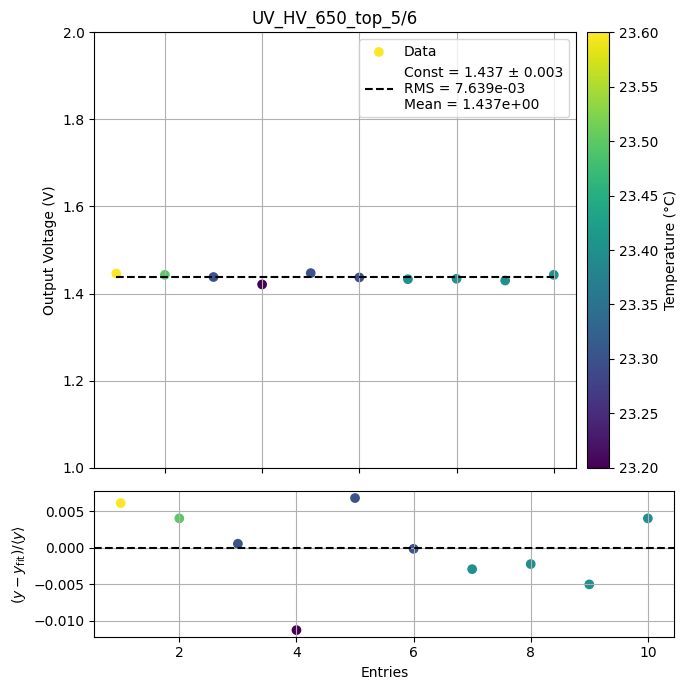

In [56]:
plot_OV("UV_HV_650_top_5/6", data_dict, results_dict)

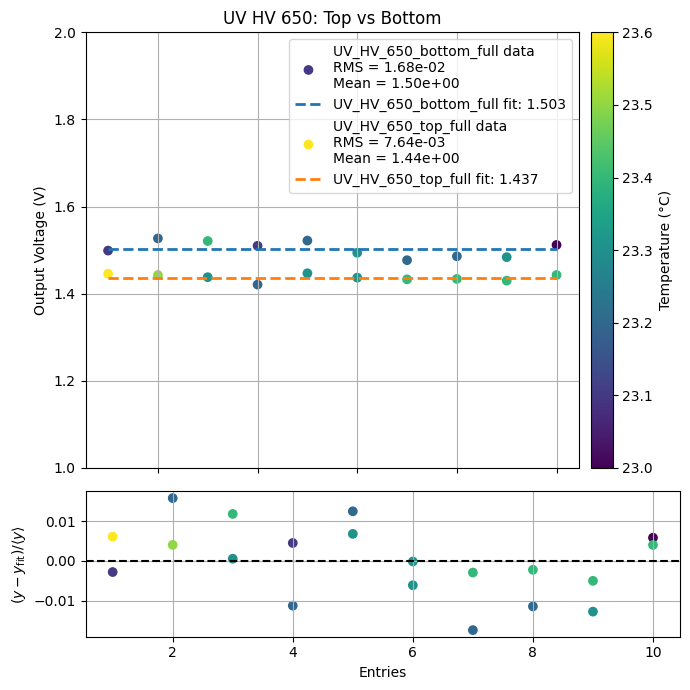

In [57]:
plot_OV_overlay(
    ["UV_HV_650_bottom_full", "UV_HV_650_top_full"],
    data_dict,
    results_dict
)

In [23]:
0.06/1.5

0.04

Plots a category

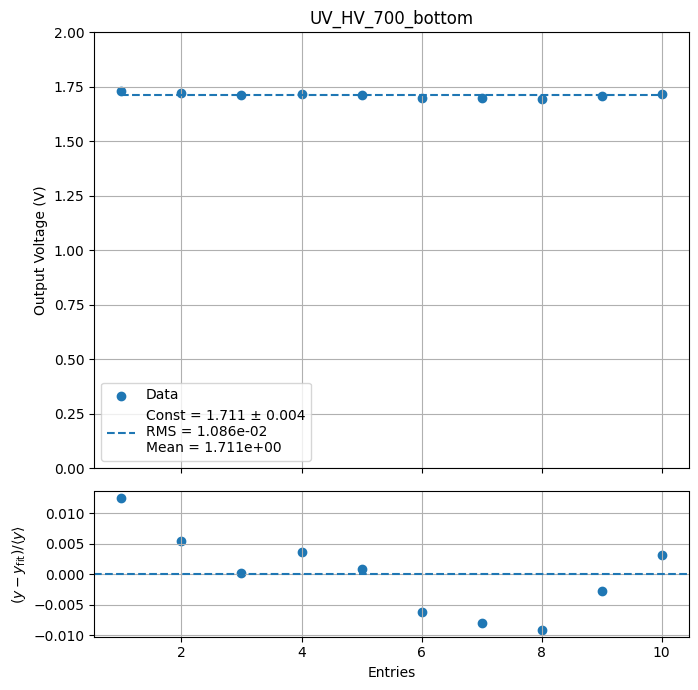

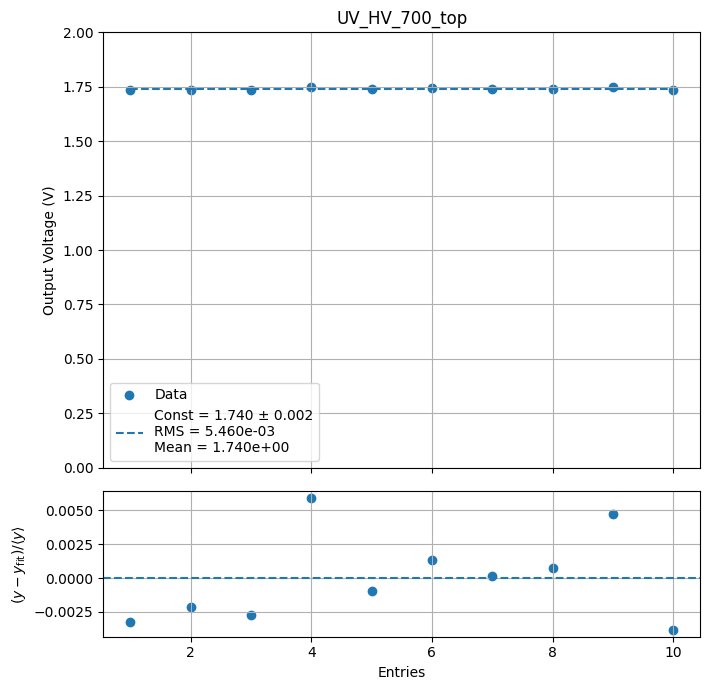

In [199]:
# for name, info in data_dict.items():
#     # if info["title"] == "UV_HV_700_bottom":
#     if "UV_HV_700" in info["title"]:
#         # plot_HV_vs_OV(name, data_dict, results_dict)
#         # plot_OA_vs_OV(name, data_dict, results_dict)
#         plot_OV(name, data_dict, results_dict)
plot_OV("UV_HV_700_bottom", data_dict, results_dict)
plot_OV("UV_HV_700_top", data_dict, results_dict)



Access results

In [ ]:
for name, res in results_dict.items():
    print(f"{name}:")
    print(f"  slope     = {res['slope']:.4f} ± {res['slope_err']:.4f}")
    print(f"  intercept = {res['intercept']:.4f}")
    print(f"  RMS       = {res['rms']:.3e}")

Plot everything

In [ ]:
for name in data_dict:
    plot_dataset(name, data_dict, results_dict)

Slope = -0.0006 ± 0.0039
Intercept = 0.4053 ± 1.4591


In [ ]:
rms_y = np.sqrt(np.mean((y  - np.mean(y))**2))
print(f"RMS(y) = {rms_y:.4f}")